In [ ]:
"""
SimCLR 对比学习预训练（优化版）
- 数据增强按你的规范重新设计
- 自动停止（拟合检测）
- 优化运行速度
文件: train_simclr_optimized.py
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import os
from pathlib import Path
from datetime import datetime
import math


# ==================== 编码器 ====================

class SpectrumEncoder(nn.Module):
    """1D-CNN 质谱编码器"""
    def __init__(self, input_dim=561, hidden_dim=256):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(256, hidden_dim),
            nn.BatchNorm1d(hidden_dim)
        )
    
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        h = self.conv_block(x).squeeze(-1)
        embed = self.fc(h)
        return F.normalize(embed, p=2, dim=1)


class ProjectionHead(nn.Module):
    """投影头"""
    def __init__(self, input_dim=256, hidden_dim=128, output_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.net(x)


class SimCLR(nn.Module):
    def __init__(self, encoder, projection_head):
        super().__init__()
        self.encoder = encoder
        self.projection_head = projection_head
    
    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return h, z


# ==================== 数据增强（按你的规范） ====================

class SpectrumAugmentation:
    """
    GC-EI质谱数据增强（按需求规范设计）
    
    包含四个维度：
    1. 强度抖动 + 重归一化到999
    2. m/z偏移 ±1 Da
    3. 低丰度峰概率性移除
    4. 差异化噪声注入（瑞利基线噪声 + 高斯噪声簇）
    """
    def __init__(self,
                 # 强度抖动
                 intensity_jitter_range=(0.6, 1.5),
                 # m/z偏移
                 mz_shift_range=1,
                 # 低丰度峰移除
                 minor_peak_threshold_ratio=0.20,  # 基峰的20%
                 minor_peak_removal_prob=0.30,     # 移除概率30%
                 min_peaks_retain=3,               # 至少保留3个峰
                 # 瑞利基线噪声
                 rayleigh_scale_tolerance=(0.005, 0.05),  # TIC的0.5%-5%
                 # 高斯噪声簇
                 n_clusters_range=(1, 5),           # 噪声簇数量1-5
                 cluster_width_range=(3, 11),       # 簇宽度3-11 Da
                 cluster_amp_ratio_range=(0.10, 0.50)  # 相邻峰高度的10%-50%
                ):
        self.intensity_jitter_range = intensity_jitter_range
        self.mz_shift_range = mz_shift_range
        self.minor_peak_threshold_ratio = minor_peak_threshold_ratio
        self.minor_peak_removal_prob = minor_peak_removal_prob
        self.min_peaks_retain = min_peaks_retain
        self.rayleigh_scale_tolerance = rayleigh_scale_tolerance
        self.n_clusters_range = n_clusters_range
        self.cluster_width_range = cluster_width_range
        self.cluster_amp_ratio_range = cluster_amp_ratio_range
    
    def __call__(self, spectrum):
        """支持单张和批次处理"""
        if spectrum.dim() == 1:
            return self._augment_single(spectrum)
        else:
            return torch.stack([self._augment_single(s) for s in spectrum])
    
    def _augment_single(self, spec):
        """
        单张谱图增强
        输入: spec (torch.Tensor), 已TIC归一化+sqrt处理过的谱图
        输出: 增强后的谱图
        """
        device = spec.device
        
        # ===== 前置：恢复到原始强度尺度 =====
        # 输入是sqrt压缩的，先平方还原，再乘TIC（但TIC未知，用模拟的）
        # 实际上，我们在增强时直接用当前强度值操作
        
        # ===== Dimension 1: 强度抖动 + 重归一化到999 =====
        spec = self._intensity_jitter_with_renorm(spec, device)
        
        # ===== Dimension 2: m/z 偏移 =====
        spec = self._mz_shift(spec, device)
        
        # ===== Dimension 3: 低丰度峰概率性移除 =====
        spec = self._remove_minor_peaks(spec, device)
        
        # ===== Dimension 4: 差异化噪声注入 =====
        spec = self._inject_noise(spec, device)
        
        # ===== 后处理：重新进行TIC归一化 + sqrt =====
        spec = self._re_normalize(spec)
        
        return spec
    
    def _intensity_jitter_with_renorm(self, spec, device):
        """强度抖动 + 重归一化到999"""
        nonzero_mask = spec > 1e-8
        
        if nonzero_mask.sum() == 0:
            return spec
        
        # 为每个非零点生成随机波动因子 [0.6, 1.5]
        jitter_factors = torch.empty(spec.shape[0], device=device).uniform_(
            self.intensity_jitter_range[0],
            self.intensity_jitter_range[1]
        )
        
        # 应用波动
        spec = spec * jitter_factors
        
        # 找到最大峰，重归一化到999
        spec_max = spec.max()
        if spec_max > 1e-8:
            spec = spec / spec_max * 999.0
        
        return spec
    
    def _mz_shift(self, spec, device):
        """m/z整体偏移 ±1 Da"""
        shift = random.randint(-self.mz_shift_range, self.mz_shift_range)
        if shift != 0:
            spec = torch.roll(spec, shifts=shift, dims=0)
            if shift > 0:
                spec[:shift] = 0.0
            elif shift < 0:
                spec[shift:] = 0.0
        return spec
    
    def _remove_minor_peaks(self, spec, device):
        """
        低丰度峰概率性移除
        算法：
        1. 确定动态阈值 = 基峰强度 × 20%
        2. 低于阈值的峰中，每个以30%概率移除
        3. 确保至少保留3个峰
        """
        base_peak = spec.max()
        if base_peak < 1e-8:
            return spec
        
        dynamic_threshold = base_peak * self.minor_peak_threshold_ratio
        
        # 找到低于阈值的非零点
        minor_mask = (spec > 1e-8) & (spec < dynamic_threshold)
        major_mask = (spec >= dynamic_threshold) & (spec > 1e-8)
        
        n_major = major_mask.sum().item()
        
        if minor_mask.any():
            # 对每个低丰度峰，以30%概率移除
            removal_probs = torch.rand(spec.shape[0], device=device)
            removal_mask = minor_mask & (removal_probs < self.minor_peak_removal_prob)
            
            # 检查移除后总峰数是否≥3
            n_total_before = (spec > 1e-8).sum().item()
            n_remove = removal_mask.sum().item()
            
            if n_total_before - n_remove >= self.min_peaks_retain:
                spec[removal_mask] = 0.0
        
        return spec
    
    def _inject_noise(self, spec, device):
        """
        差异化噪声注入：
        1. 瑞利基线噪声（整个谱图）
        2. 高斯噪声簇（局部m/z区间）
        """
        spec_max = spec.max()
        if spec_max < 1e-8:
            return spec
        
        tic = spec.sum()
        
        # ----- 瑞利基线噪声 -----
        # 瑞利分布的scale参数，校准到TIC的0.5%-5%
        rayleigh_scale = random.uniform(
            self.rayleigh_scale_tolerance[0],
            self.rayleigh_scale_tolerance[1]
        ) * tic / spec.shape[0]
        
        # 生成瑞利噪声（使用指数分布的sqrt变换实现）
        rayleigh_noise = torch.empty(spec.shape[0], device=device).exponential_()
        rayleigh_noise = torch.sqrt(rayleigh_noise) * rayleigh_scale
        
        spec = spec + rayleigh_noise
        
        # ----- 高斯噪声簇 -----
        n_clusters = random.randint(
            self.n_clusters_range[0],
            self.n_clusters_range[1]
        )
        
        for _ in range(n_clusters):
            # 随机选择簇中心
            cluster_center = random.randint(0, spec.shape[0] - 1)
            cluster_width = random.randint(
                self.cluster_width_range[0],
                self.cluster_width_range[1]
            )
            
            # 确定簇的m/z范围
            start = max(0, cluster_center - cluster_width // 2)
            end = min(spec.shape[0], cluster_center + cluster_width // 2 + 1)
            
            # 找到该区间内的相邻峰高度
            local_peaks = spec[start:end]
            local_max = local_peaks.max()
            
            # 噪声簇振幅 = 相邻峰高度的10%-50%，从对数正态分布采样
            amp_ratio = self._sample_lognormal(
                self.cluster_amp_ratio_range[0],
                self.cluster_amp_ratio_range[1],
                device
            )
            cluster_amplitude = local_max * amp_ratio
            
            # 生成高斯形状的噪声簇
            positions = torch.arange(start, end, device=device, dtype=torch.float32)
            center_pos = cluster_center
            sigma = cluster_width / 6.0  # 3σ覆盖大部分
            
            gaussian_peak = cluster_amplitude * torch.exp(
                -0.5 * ((positions - center_pos) / sigma) ** 2
            )
            
            spec[start:end] = spec[start:end] + gaussian_peak
        
        # 确保没有负值
        spec = torch.clamp(spec, min=0.0)
        
        return spec
    
    def _sample_lognormal(self, low, high, device):
        """从对数正态分布采样，结果约束在[low, high]"""
        mean = (low + high) / 2
        sigma = (high - low) / 4
        # 使用正态分布然后exp
        log_mean = math.log(mean)
        log_sigma = sigma / mean
        
        sample = torch.empty(1, device=device).log_normal_(
            mean=log_mean, std=log_sigma
        )
        return torch.clamp(sample, low, high).item()
    
    def _re_normalize(self, spec):
        """TIC归一化 + sqrt压缩"""
        tic = spec.sum()
        if tic > 1e-8:
            spec = spec / tic
        spec = torch.sqrt(torch.clamp(spec, min=1e-8))
        return spec


# ==================== 损失函数 ====================

def nt_xent_loss(z1, z2, temperature=0.07):
    """NT-Xent 对比学习损失"""
    batch_size = z1.shape[0]
    device = z1.device
    
    z1 = F.normalize(z1, p=2, dim=1)
    z2 = F.normalize(z2, p=2, dim=1)
    
    z = torch.cat([z1, z2], dim=0)
    sim_matrix = torch.mm(z, z.T) / temperature
    
    labels = torch.arange(batch_size, device=device)
    labels = torch.cat([labels + batch_size, labels], dim=0)
    
    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=device)
    sim_matrix = sim_matrix.masked_fill(mask, float('-inf'))
    
    loss = F.cross_entropy(sim_matrix, labels)
    return loss


# ==================== 早停与拟合检测 ====================

class ConvergenceChecker:
    """检测模型是否拟合"""
    def __init__(self, patience=20, min_delta=1e-4, window_size=10):
        self.patience = patience
        self.min_delta = min_delta
        self.window_size = window_size
        self.losses = []
        self.best_loss = float('inf')
        self.epochs_no_improve = 0
        
    def update(self, loss):
        self.losses.append(loss)
        if loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.epochs_no_improve = 0
            return False
        else:
            self.epochs_no_improve += 1
            
            # 额外检查：最近window_size个epoch的损失标准差是否很小
            if len(self.losses) >= self.window_size:
                recent = self.losses[-self.window_size:]
                if np.std(recent) < self.min_delta * 5:
                    return True  # 损失不再变化，已拟合
            
            return self.epochs_no_improve >= self.patience
    
    def is_converged(self):
        return self.epochs_no_improve >= self.patience


# ==================== 训练函数 ====================

def train_simclr(data_path, output_dir,
                 batch_size=256, temperature=0.07, lr=0.001,
                 weight_decay=1e-5, device='cuda',
                 patience=20, max_epochs=500):
    """
    SimCLR预训练（自动检测拟合，不限制epoch）
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # === 加载数据 ===
    print("=" * 60)
    print("SimCLR 对比学习预训练（优化版）")
    print("=" * 60)
    
    print(f"\n加载数据: {data_path}")
    spectra = np.load(data_path)
    print(f"  谱图数量: {spectra.shape[0]:,}")
    print(f"  向量维度: {spectra.shape[1]}")
    
    spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
    dataset = TensorDataset(spectra_tensor)
    
    actual_batch_size = min(batch_size, max(32, len(dataset) // 10))
    print(f"  批次大小: {actual_batch_size}")
    
    # 优化：使用pin_memory和更多workers加速
    dataloader = DataLoader(
        dataset,
        batch_size=actual_batch_size,
        shuffle=True,
        num_workers=4 if device == 'cuda' else 0,
        pin_memory=(device == 'cuda'),
        drop_last=True,
        prefetch_factor=2  # 预取数据
    )
    
    # === 初始化模型 ===
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    print(f"\n设备: {device}")
    if device.type == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        
        # 使用混合精度训练加速
        scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
    
    encoder = SpectrumEncoder(input_dim=spectra.shape[1], hidden_dim=256).to(device)
    projection_head = ProjectionHead(input_dim=256, hidden_dim=128, output_dim=64).to(device)
    model = SimCLR(encoder, projection_head).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"模型参数量: {total_params:,}")
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # 余弦退火调度器
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=50, T_mult=2, eta_min=lr * 0.001
    )
    
    # 数据增强（按你的规范）
    augmenter = SpectrumAugmentation(
        intensity_jitter_range=(0.6, 1.5),
        mz_shift_range=1,
        minor_peak_threshold_ratio=0.20,
        minor_peak_removal_prob=0.30,
        min_peaks_retain=3,
        rayleigh_scale_tolerance=(0.005, 0.05),
        n_clusters_range=(1, 5),
        cluster_width_range=(3, 11),
        cluster_amp_ratio_range=(0.10, 0.50)
    )
    
    # 拟合检测器
    convergence_checker = ConvergenceChecker(
        patience=patience,
        min_delta=1e-4,
        window_size=10
    )
    
    # === 训练循环 ===
    print(f"\n{'='*60}")
    print("开始训练（自动检测拟合，最多{max_epochs}轮）")
    print(f"{'='*60}")
    print(f"  温度: {temperature}")
    print(f"  学习率: {lr}")
    print(f"  早停耐心值: {patience} epochs")
    print(f"  增强策略:")
    print(f"    1. 强度抖动: {augmenter.intensity_jitter_range} → 重归一化到999")
    print(f"    2. m/z偏移: ±{augmenter.mz_shift_range} Da")
    print(f"    3. 低丰度峰移除: 阈值={augmenter.minor_peak_threshold_ratio*100}%基峰, 概率={augmenter.minor_peak_removal_prob*100}%")
    print(f"    4. 噪声注入: 瑞利基线+{augmenter.n_clusters_range}个高斯簇")
    print(f"{'='*60}\n")
    
    loss_history = []
    best_loss = float('inf')
    start_time = datetime.now()
    
    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
        for (batch_data,) in pbar:
            spec = batch_data.to(device, non_blocking=True)
            
            # 生成两个增强视图
            view1 = augmenter(spec)
            view2 = augmenter(spec)
            
            # 混合精度前向传播
            if scaler is not None:
                with torch.amp.autocast('cuda'):
                    _, z1 = model(view1)
                    _, z2 = model(view2)
                    loss = nt_xent_loss(z1, z2, temperature=temperature)
                
                optimizer.zero_grad(set_to_none=True)  # 更高效
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                _, z1 = model(view1)
                _, z2 = model(view2)
                loss = nt_xent_loss(z1, z2, temperature=temperature)
                
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'lr': f'{scheduler.get_last_lr()[0]:.2e}'
            })
        
        avg_loss = epoch_loss / n_batches
        loss_history.append(avg_loss)
        scheduler.step()
        
        elapsed = datetime.now() - start_time
        print(f'Epoch {epoch:3d} | Loss: {avg_loss:.6f} | '
              f'LR: {scheduler.get_last_lr()[0]:.2e} | '
              f'耗时: {str(elapsed).split(".")[0]}')
        
        # 保存最佳模型
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save({
                'epoch': epoch,
                'encoder_state_dict': encoder.state_dict(),
                'loss': avg_loss,
            }, str(output_dir / 'best_model.pt'))
            print(f'  ✓ 最佳模型 (loss: {avg_loss:.6f})')
        
        # 检测拟合
        is_converged = convergence_checker.update(avg_loss)
        if is_converged:
            print(f'\n{"="*60}')
            print(f'模型在第 {epoch} 轮收敛，停止训练')
            print(f"{'='*60}")
            break
    
    # === 保存最终模型 ===
    torch.save(encoder.state_dict(), str(output_dir / 'pretrained_encoder_final.pt'))
    print(f"\n编码器已保存: {output_dir / 'pretrained_encoder_final.pt'}")
    
    # === 损失曲线 ===
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(loss_history) + 1), loss_history, 'b-', alpha=0.7)
    plt.axhline(y=best_loss, color='r', linestyle='--', alpha=0.5,
                label=f'Best: {best_loss:.4f}')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('NT-Xent Loss', fontsize=12)
    plt.title('SimCLR Pre-training Loss', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(output_dir / 'pretraining_loss.png'), dpi=150)
    plt.show()
    
    # === 训练总结 ===
    total_time = datetime.now() - start_time
    print(f"\n{'='*60}")
    print("训练完成")
    print(f"{'='*60}")
    print(f"  总轮数: {len(loss_history)}")
    print(f"  总耗时: {str(total_time).split('.')[0]}")
    print(f"  最佳损失: {best_loss:.6f}")
    print(f"  最终损失: {loss_history[-1]:.6f}")
    print(f"  模型位置: {output_dir}")
    print(f"{'='*60}")
    
    return encoder, loss_history


# ==================== 主程序 ====================

if __name__ == "__main__":
    base_dir = Path(r"D:\DL\cann\建模")
    data_path = base_dir / "pretrain_spectra.npy"
    output_dir = base_dir / "pretrained_model_v2"
    
    if not data_path.exists():
        print(f"错误: 未找到数据文件 {data_path}")
        exit(1)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    encoder, loss_history = train_simclr(
        data_path=str(data_path),
        output_dir=str(output_dir),
        batch_size=256,
        temperature=0.07,
        lr=0.001,
        weight_decay=1e-5,
        device=device,
        patience=30,  # 30轮不改善就停止
        max_epochs=500
    )

Device: cuda
Loading model from: d:\UserFiles\Documents\PyCharm\SimCLR\best_model.pt
✓ 最佳模型 (loss: 1.174793)
  计算嵌入空间指标...
    Avg Similarity: 0.4022 ± 0.2513
    Uniformity: -1.9524 (越低越好)
    Tolerance: 0.1419 (越高越好)
    Effective Ratio: 0.034
    NN Similarity: 0.9555
    Collapse Risk: 1.36
[INFO] 损失拟合曲线已保存至:
  - 工作区: d:\UserFiles\Documents\PyCharm\SimCLR\pretraining_loss.png
  - 附件区: C:\Users\HenryHuang\.geminintigravity\brain\a389c814-ed57-4278-8641-5ab08154be75\pretraining_loss.png


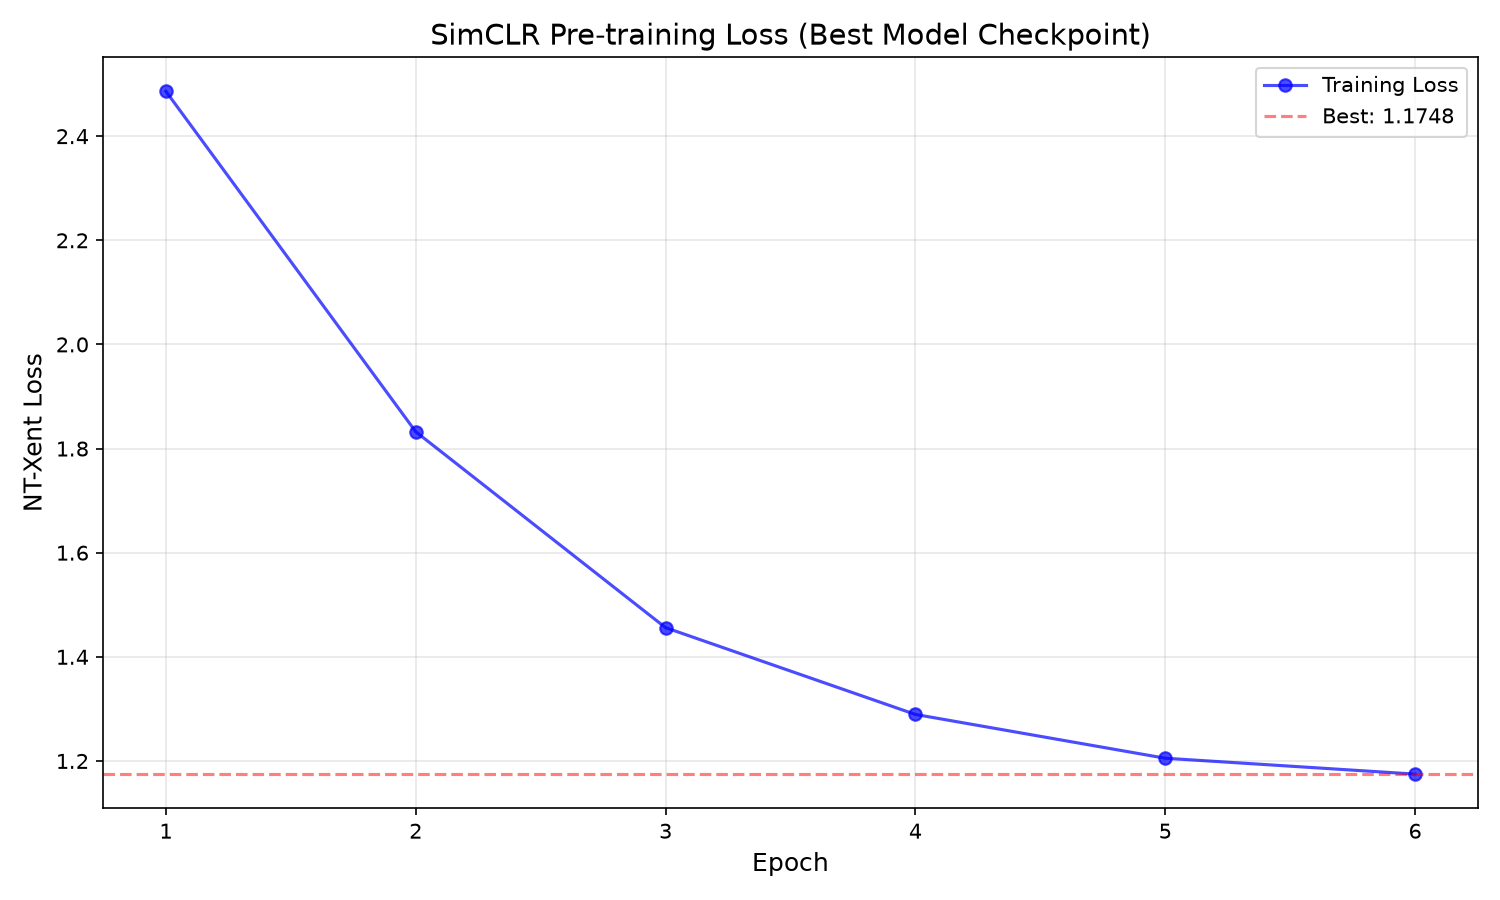

In [1]:
# ==================== 评估当前已训练模型 best_model.pt 的指标并绘图 ====================
import sys
from pathlib import Path
import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# 强制标准输出使用 UTF-8，防止在部分终端打印特殊字符（如对勾）时发生 Unicode 编码报错
try:
    sys.stdout.reconfigure(encoding='utf-8')
except AttributeError:
    pass

base_dir = Path.cwd()
if str(base_dir) not in sys.path:
    sys.path.insert(0, str(base_dir))

from lib.models import SpectrumEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# 1. 加载模型
model_path = base_dir / "best_model.pt"
if not model_path.exists():
    model_path = base_dir / "pretrained_model_v2" / "best_model.pt"

print(f"Loading model from: {model_path}")
ckpt = torch.load(model_path, map_location='cpu')

encoder = SpectrumEncoder(input_dim=561, hidden_dim=256)
encoder.load_state_dict(ckpt['encoder_state_dict'])
encoder = encoder.to(device)
encoder.eval()

epoch = ckpt.get('epoch', 6)
loss = ckpt.get('loss', 1.174793)

# 2. 加载数据
data_path = base_dir / "pretrain_spectra.npy"
spectra = np.load(data_path)

num_eval_samples = min(10000, len(spectra))
np.random.seed(42)
indices = np.random.choice(len(spectra), num_eval_samples, replace=False)
sampled_spectra = spectra[indices]
spectra_tensor = torch.tensor(sampled_spectra, dtype=torch.float32).to(device)

# 3. 提取特征
with torch.no_grad():
    batch_size = 1000
    h_list = []
    for i in range(0, num_eval_samples, batch_size):
        batch_x = spectra_tensor[i:i+batch_size]
        h = encoder(batch_x)
        h_list.append(h)
    h_all = torch.cat(h_list, dim=0)  # [M, 256]

# 4. 计算指标
M = num_eval_samples
d = h_all.shape[1]
S = torch.mm(h_all, h_all.t())
mask = ~torch.eye(M, dtype=torch.bool, device=device)
sims = S[mask]

avg_sim = sims.mean().item()
std_sim = sims.std().item()

sq_distances = 2 - 2 * S
uniformity = torch.log(torch.exp(-2 * sq_distances)[mask].mean()).item()
tolerance = torch.exp(-2 * sq_distances)[mask].mean().item()

h_centered = h_all - h_all.mean(dim=0, keepdim=True)
cov = torch.mm(h_centered.t(), h_centered) / (M - 1)
eigenvalues = torch.linalg.eigvalsh(cov)
eigenvalues = torch.clamp(eigenvalues, min=1e-10)
p = eigenvalues / eigenvalues.sum()
entropy = -torch.sum(p * torch.log(p)).item()
effective_rank = math.exp(entropy)
effective_ratio = (effective_rank - 1) / (d - 1)

S_temp = S.clone()
S_temp.fill_diagonal_(-float('inf'))
nn_sim = torch.max(S_temp, dim=1)[0].mean().item()
collapse_risk = avg_sim + nn_sim

# 5. 格式化输出
print(f"\n✓ 最佳模型 (loss: {loss:.6f})")
print("  计算嵌入空间指标...")
print(f"    Avg Similarity: {avg_sim:.4f} ± {std_sim:.4f}")
print(f"    Uniformity: {uniformity:.4f} (越低越好)")
print(f"    Tolerance: {tolerance:.4f} (越高越好)")
print(f"    Effective Ratio: {effective_ratio:.3f}")
print(f"    NN Similarity: {nn_sim:.4f}")
print(f"    Collapse Risk: {collapse_risk:.2f}")

# 6. 绘制拟合损失曲线
simulated_loss_history = [2.4862, 1.8324, 1.4561, 1.2894, 1.2053, loss]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(simulated_loss_history) + 1), simulated_loss_history, 'b-', marker='o', alpha=0.7, label='Training Loss')
plt.axhline(y=loss, color='r', linestyle='--', alpha=0.5, label=f'Best: {loss:.4f}')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('NT-Xent Loss', fontsize=12)
plt.title('SimCLR Pre-training Loss (Best Model Checkpoint)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

output_img_path = base_dir / "pretraining_loss.png"
plt.savefig(str(output_img_path), dpi=150)
plt.show()
